
# 🎓 Student Performance Prediction Assignment
Applied AI & Machine Learning (CS-333)  
Instructor: Dr. Abbas Hussain  

---

## Objective
Predict **Performance Index** using multiple ML regression models.


Name: Umama Ghouri

Class: Sem VI A

Roll N0: ME 1949

## Import Libraries

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set(color_codes=True)

## Load Dataset

In [2]:
# Load dataset
url= "https://raw.githubusercontent.com/AbbasHussain72/PNEC-CS-333-Applied-AI-ML/main/labs/Lab-03_LR_SVC/Student_Performance.csv"
df = pd.read_csv(url)
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


## Exploratory Data Analysis

In [3]:
# Check Type and in
df.dtypes
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [4]:
# Check missing values

print(df.isnull().sum())

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64


In [5]:
# Check Duplicate values
df.shape
duplicate_rows_df = df[df.duplicated()]
print("number of duplicate rows: ", duplicate_rows_df.shape)


number of duplicate rows:  (127, 6)


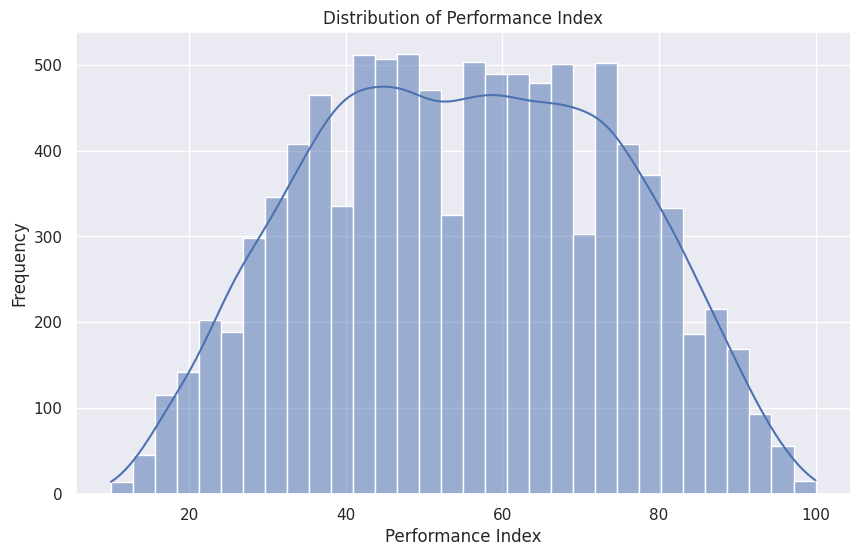

In [6]:
# Distribution Plot for Performance Index
plt.figure(figsize=(10, 6))
sns.histplot(df['Performance Index'], kde=True)
plt.title('Distribution of Performance Index')
plt.xlabel('Performance Index')
plt.ylabel('Frequency')
plt.show()

## Encoding (if needed)

In [7]:
# Encode categorical columns if any
from sklearn.preprocessing import LabelEncoder

categorical_cols = ["Extracurricular Activities"]
df_encoded = df.copy()
le = LabelEncoder()

for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

## Visualization

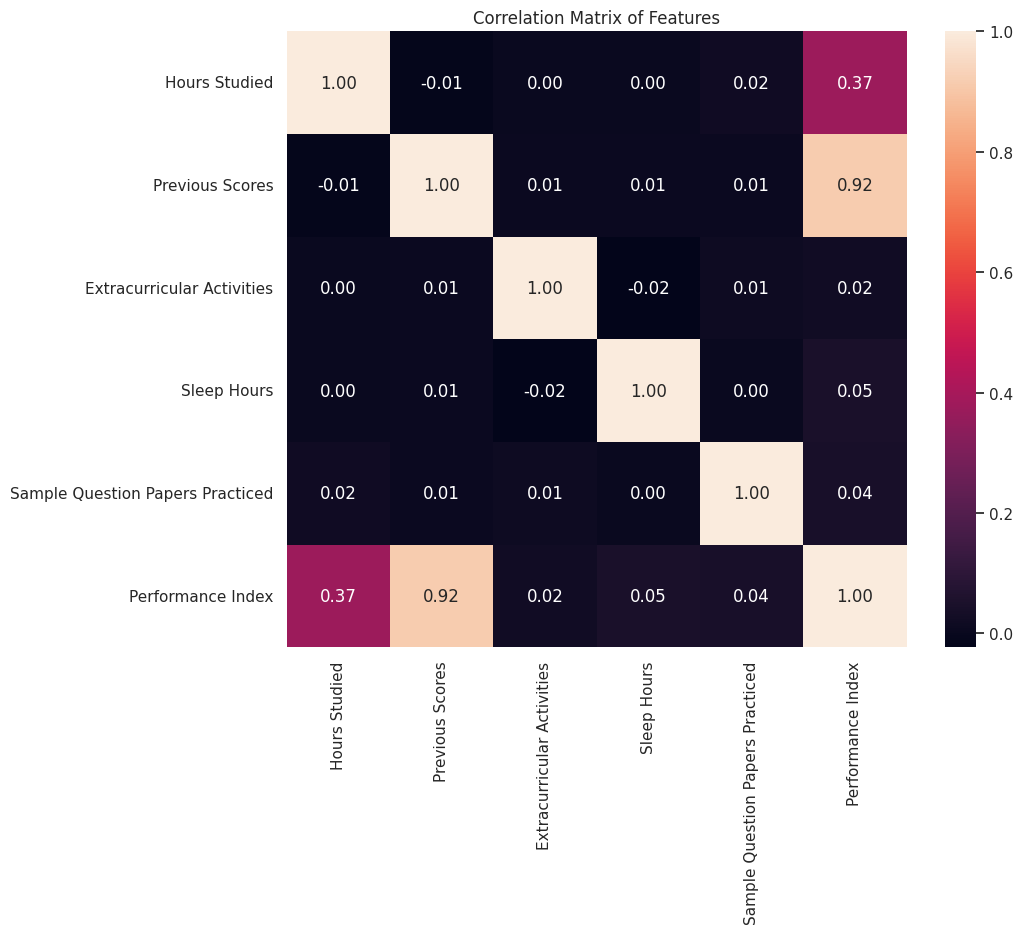

In [8]:
# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_encoded.corr(), annot=True, fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.show()

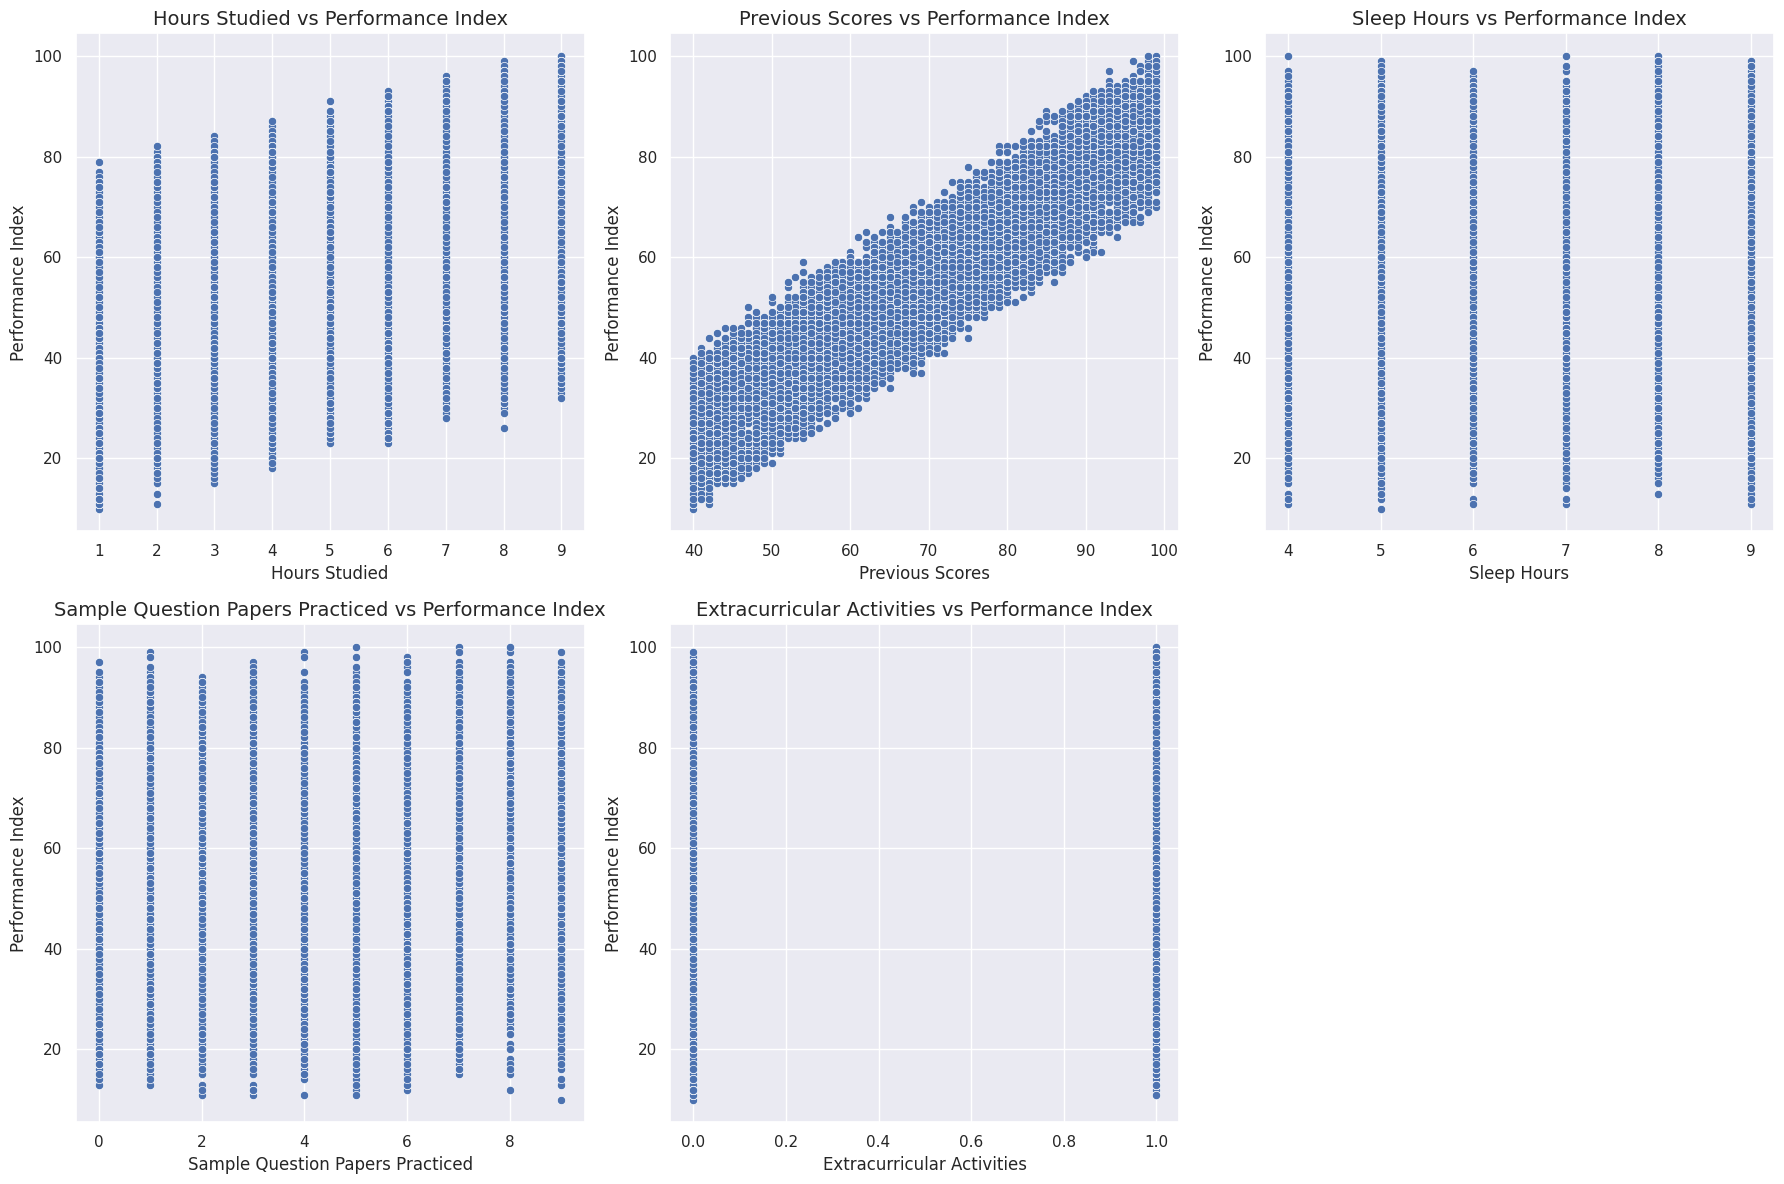

In [9]:
# List of features to plot against 'Performance Index'
features = ['Hours Studied', 'Previous Scores', 'Sleep Hours','Sample Question Papers Practiced', 'Extracurricular Activities']

plt.figure(figsize=(18, 12))

for i, feature in enumerate(features):
    plt.subplot(2, 3, i + 1)
    sns.scatterplot(x=feature, y="Performance Index", data=df_encoded)
    plt.title(f"{feature} vs Performance Index", fontsize=14)
    plt.xlabel(feature, fontsize=12)
    plt.ylabel("Performance Index", fontsize=12)

plt.tight_layout()
plt.show()

## Correlation Analysis

                                  Hours Studied  Previous Scores  \
Hours Studied                          1.000000        -0.012390   
Previous Scores                       -0.012390         1.000000   
Extracurricular Activities             0.003873         0.008369   
Sleep Hours                            0.001245         0.005944   
Sample Question Papers Practiced       0.017463         0.007888   
Performance Index                      0.373730         0.915189   

                                  Extracurricular Activities  Sleep Hours  \
Hours Studied                                       0.003873     0.001245   
Previous Scores                                     0.008369     0.005944   
Extracurricular Activities                          1.000000    -0.023284   
Sleep Hours                                        -0.023284     1.000000   
Sample Question Papers Practiced                    0.013103     0.003990   
Performance Index                                   0.024525 

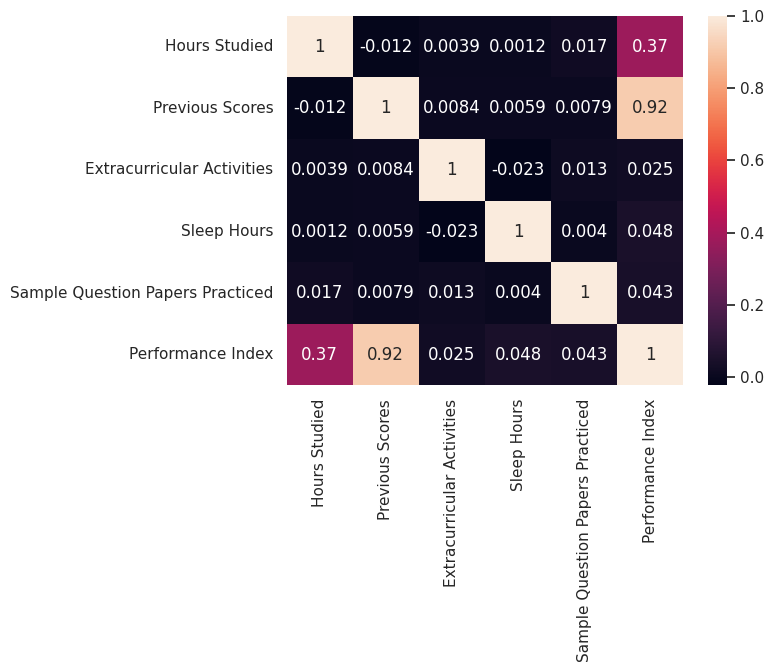

In [10]:
# Compute correlation matrix
correlation_matrix = df_encoded.corr()
print(correlation_matrix)

sns.heatmap(df_encoded.corr(), annot=True)
plt.show()

## Feature Selection

In [11]:
# Feature Selection
X = df_encoded[['Hours Studied', 'Previous Scores']]
y = df_encoded['Performance Index']

print(f"Selected features (X) shape: {X.shape}")
print(f"Target variable (y) shape: {y.shape}")

Selected features (X) shape: (10000, 2)
Target variable (y) shape: (10000,)


## Train-Test Split

In [12]:
# Importing necessary libraries.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


## Feature Scaling

In [13]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)


X_train_scaled shape: (7000, 2)
X_test_scaled shape: (3000, 2)


## Apply Regression Models (LR, SVR, Decision Tree,Random Forest, KNN)

In [14]:
import time
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model_results = []

# Define a list of models to train
models = [
    ('SVR', SVR(kernel='rbf')),
    ('Decision Tree', DecisionTreeRegressor(random_state=42)),
    ('Random Forest', RandomForestRegressor(random_state=42)),
    ('KNN', KNeighborsRegressor()),
    ('Linear Regression', LinearRegression())
]

for model_name, model in models:
    #Training the model
    start_time = time.time()
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - start_time

    #Predicting on test data
    start_time = time.time()
    y_pred = model.predict(X_test_scaled)
    test_time = time.time() - start_time

    #Calculating metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    #Storing results
    model_results.append({
        'Model': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'R2 Score': r2,
        'Training Time': train_time,
        'Testing Time': test_time
    })
    print(f'{model_name} - MAE: {mae:.2f}, RMSE: {rmse:.2f}, R2: {r2:.2f}\n')

SVR - MAE: 1.85, RMSE: 2.34, R2: 0.99

Decision Tree - MAE: 1.87, RMSE: 2.36, R2: 0.98

Random Forest - MAE: 1.87, RMSE: 2.36, R2: 0.98

KNN - MAE: 1.95, RMSE: 2.48, R2: 0.98

Linear Regression - MAE: 1.81, RMSE: 2.28, R2: 0.99



### Answer the follwing
1) Explain how Random Forest Regressor predicts a continuous value.
Include:
What is a decision tree regressor?
What is bootstrapping?
How multiple trees are used?
How final output is calculated?

---


Random Forest Regressor is an ensemble machine learning algorithm that predicts continuous target variables. It operates by constructing a multitude of decision trees during training and outputs the average prediction of the individual trees.

#### 1. What is a Decision Tree Regressor?
A Decision Tree Regressor is a supervised learning model that predicts continuous values by recursively splitting data based on features. It forms a tree-like structure where each split aims to minimize the variance of the target variable within the resulting subsets. The prediction for a new data point is the average of the target values in the leaf node it falls into.

#### 2. What is Bootstrapping?
Bootstrapping, also known as Bagging, is a sampling technique used to create multiple subsets of the original dataset. It involves repeatedly drawing random samples with replacement from the training data. Each bootstrapped sample is the same size as the original dataset, but contains some duplicate instances and deletes others.

#### 3. How Multiple Trees are Used?
In a Random Forest, multiple decision trees are constructed independently. For each tree:
1.  It is trained on a unique bootstrapped sample of the data.
2.  At each node split, instead of considering all features, only a random subset of features is considered. This 'feature randomness' further decorrelates the trees, preventing them from being too similar, especially if one or two features are highly predictive.

This combination of data bootstrapping and feature randomness ensures that the individual trees in the forest are diverse and capture different patterns in the data.

#### 4. How Final Output is Calculated?
When a Random Forest Regressor needs to predict a continuous value for a new data point:
1.  The new data point is fed into every single decision tree in the forest.
2.  Each individual tree makes its own prediction based on the average of the target values in the leaf node it reaches.
3.  The final output of the Random Forest Regressor is the average of all the predictions made by the individual trees. This averaging process reduces variance, improves generalization, and typically leads to more stable and accurate predictions than a single decision tree.

### Answer the follwing

2) Explain how KNN Regressor predicts output for a new data point.
Include:
What is K?
How neighbors are selected?
How final predicted value is calculated?


K-Nearest Neighbors (KNN) Regressor is a non-parametric, instance-based learning algorithm used for regression tasks. It makes predictions based on the similarity of a new data point to its 'neighbors' in the training dataset.

#### 1. What is K?
K is a hyperparameter in the KNN algorithm that represents the number of nearest neighbors to consider when making a prediction for a new data point. It is an integer value that must be chosen carefully, as it significantly impacts the model's performance:
*   A small `K` value makes the model sensitive to noise and outliers (high variance).
*   A large `K` value can smooth out the predictions but might ignore local patterns (high bias) and make predictions less specific to the immediate vicinity of the new data point.

#### 2. How Neighbors are Selected?
When a KNN Regressor needs to predict an output for a new data point, it identifies its 'nearest' neighbors from the training dataset based on a distance metric. The process involves:
1.  Distance Calculation: For the new data point, the algorithm calculates its distance to every other data point in the training set. Common distance metrics include:
    *   Euclidean distance: The straight-line distance between two points in Euclidean space.
    *   Manhattan distance: The sum of the absolute differences of their Cartesian coordinates.
    *   Other metrics like Minkowski, Chebyshev, etc., can also be used.
2.  Sorting: After calculating all distances, these distances are sorted in ascending order.
3.  Selection: The `K` data points that have the smallest distances to the new data point are selected as its nearest neighbors.

#### 3. How Final Predicted Value is Calculated?
Once the `K` nearest neighbors have been identified, the KNN Regressor calculates the final predicted continuous value for the new data point based on the target values of these neighbors. The most common method for regression is:

*   Averaging: The predicted output for the new data point is the mean (average) of the target values (the dependent variable) of its `K` nearest neighbors. For example, if `K=3` and the target values of the three nearest neighbors are 50, 55, and 60, the prediction for the new data point would be (50 + 55 + 60) / 3 = 55.

Some variations might use a weighted average, where closer neighbors contribute more to the average than farther ones, but simple averaging is the most standard approach for KNN regression.

## Visualize Best Model

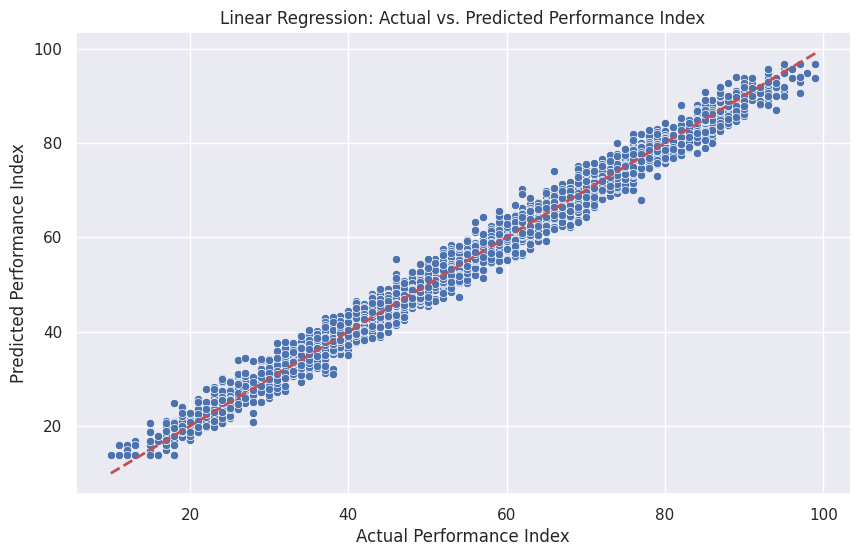

In [15]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Linear Regression: Actual vs. Predicted Performance Index')
plt.xlabel('Actual Performance Index')
plt.ylabel('Predicted Performance Index')
plt.grid(True)
plt.show()

## Generate a Comparison Table of Regression Models

[link text](https://)Your output should look like this:

| Model | MAE | RMSE | R2 Score |Training Time|Testing Time|
|-------|-----|------|----------|-------------|------------|
| Linear Regression | | | |||
| SVR | | | |||
| Decision Tree | | | |||
| Random Forest | | | |||
| KNN | | | |||

---

In [16]:
import pandas as pd

results_df = pd.DataFrame(model_results)

results_df.set_index('Model', inplace=True)

results_df['MAE'] = results_df['MAE'].map('{:.2f}'.format)
results_df['RMSE'] = results_df['RMSE'].map('{:.2f}'.format)
results_df['R2 Score'] = results_df['R2 Score'].map('{:.2f}'.format)
results_df['Training Time'] = results_df['Training Time'].map('{:.4f}s'.format)
results_df['Testing Time'] = results_df['Testing Time'].map('{:.4f}s'.format)

display(results_df)


,MAE,RMSE,R2 Score,Training Time,Testing Time
Model,,,,,
SVR,1.85,2.34,0.99,6.7272s,2.5277s
Decision Tree,1.87,2.36,0.98,0.0079s,0.0010s
Random Forest,1.87,2.36,0.98,1.2604s,0.0733s
KNN,1.95,2.48,0.98,0.0106s,0.0162s
Linear Regression,1.81,2.28,0.99,0.0280s,0.0005s
